In [38]:
!pip install -q kaggle

In [39]:
import kagglehub

path = kagglehub.dataset_download("naveedgull/tomato-leaf-disease")

print(path)

/kaggle/input/datasets/naveedgull/tomato-leaf-disease


In [40]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    print("Directories:", dirs)
    print("Files:", files[:5])  # Show first 5 files
    print("-" * 50)

/kaggle/input/datasets/naveedgull/tomato-leaf-disease
Directories: ['Tomato Leaf Disease']
Files: []
--------------------------------------------------
/kaggle/input/datasets/naveedgull/tomato-leaf-disease/Tomato Leaf Disease
Directories: ['test', 'train']
Files: []
--------------------------------------------------
/kaggle/input/datasets/naveedgull/tomato-leaf-disease/Tomato Leaf Disease/test
Directories: ['Tomato___Late_blight', 'Tomato___healthy', 'Tomato___Early_blight', 'Tomato___Septoria_leaf_spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Bacterial_spot', 'Tomato___Target_Spot', 'Tomato___Tomato_mosaic_virus', 'Tomato___Leaf_Mold', 'Tomato___Spider_mites Two-spotted_spider_mite']
Files: []
--------------------------------------------------
/kaggle/input/datasets/naveedgull/tomato-leaf-disease/Tomato Leaf Disease/test/Tomato___Late_blight
Directories: []
Files: ['image (1443).JPG', 'image (1831).JPG', 'image (1258).jpg', 'image (1063).JPG', 'image (1038).JPG']
--------

In [41]:
import os, shutil
from sklearn.model_selection import train_test_split

import os
SEED = 42

target_keywords = {
    'Leaf Mold': ['leaf_mold', 'leafmold', 'mold'],
    'Septoria Leaf Spot': ['septoria'],
}
class_dirs = {}
for root, dirs, files in os.walk(path):
    for d in dirs:
        low = d.lower()
        for clean_name, kws in target_keywords.items():
            if any(kw in low for kw in kws):
                class_dirs[clean_name] = os.path.join(root, d)

assert len(class_dirs) == 2, f"Expected 2 class dirs, found: {class_dirs}"
print(class_dirs)

base_out = "/content/tomato_split"

# Nuke any stale split from a previous run before rebuilding it
if os.path.exists(base_out):
    shutil.rmtree(base_out)

for split in ['train', 'validation', 'test']:
    for cls in class_dirs:
        os.makedirs(os.path.join(base_out, split, cls), exist_ok=True)

for cls, folder in class_dirs.items():
    files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    train_files, temp_files = train_test_split(files, test_size=0.30, random_state=SEED)
    val_files, test_files = train_test_split(temp_files, test_size=0.50, random_state=SEED)
    for split_name, split_files in [('train', train_files), ('validation', val_files), ('test', test_files)]:
        for f in split_files:
            shutil.copy(os.path.join(folder, f), os.path.join(base_out, split_name, cls, f))
    print(f"{cls}: train={len(train_files)}, val={len(val_files)}, test={len(test_files)}")
    
train_dir = os.path.join(base_out, 'train')
val_dir   = os.path.join(base_out, 'validation')
test_dir  = os.path.join(base_out, 'test')

{'Septoria Leaf Spot': '/kaggle/input/datasets/naveedgull/tomato-leaf-disease/Tomato Leaf Disease/train/Tomato___Septoria_leaf_spot', 'Leaf Mold': '/kaggle/input/datasets/naveedgull/tomato-leaf-disease/Tomato Leaf Disease/train/Tomato___Leaf_Mold'}
Septoria Leaf Spot: train=991, val=212, test=213
Leaf Mold: train=560, val=120, test=120


In [42]:
# STEP: Imports + reproducibility

import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print(f'TensorFlow version: {tf.__version__}')

results_dir = "results/tomato_lab/"
os.makedirs(results_dir, exist_ok=True)
os.makedirs('models', exist_ok=True)

gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs available: {len(gpus)}' if gpus else 'No GPU — training on CPU (slower).')

TensorFlow version: 2.20.0
GPUs available: 2


In [43]:
IMAGE_HEIGHT = 224
IMAGE_WIDTH  = 224
BATCH_SIZE   = 32
EPOCHS       = 50
LR           = 1e-3

INPUT_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH, 3)

In [44]:

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, seed=SEED, shuffle=True,
    label_mode='binary',
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, seed=SEED, shuffle=False,
    label_mode='binary',
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, seed=SEED, shuffle=False,
    label_mode='binary',
)

class_names = train_dataset.class_names 
num_classes = len(class_names)
print(f'Classes: {class_names}')

Found 1551 files belonging to 2 classes.
Found 332 files belonging to 2 classes.
Found 333 files belonging to 2 classes.
Classes: ['Leaf Mold', 'Septoria Leaf Spot']


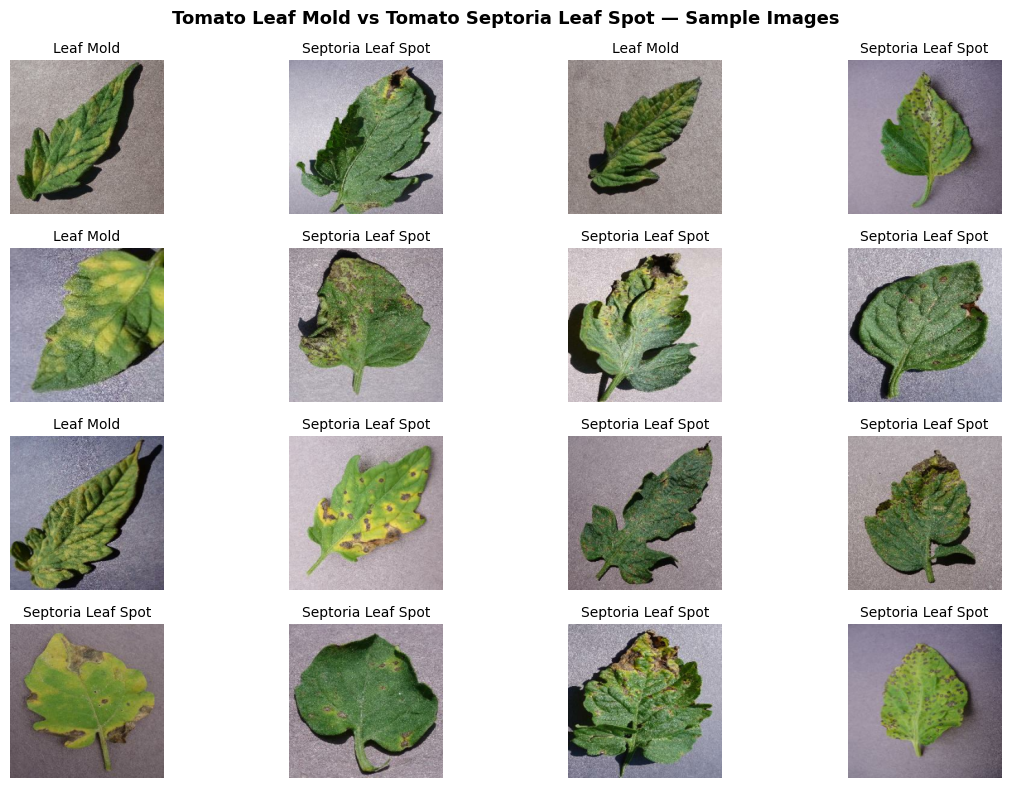

In [45]:
# STEP 3: Sanity-check a batch visually — catches wrong labels / corrupted files before you waste an hour training
for images, labels in train_dataset.take(1):
    fixed_images = images.numpy()
    fixed_labels = labels.numpy()

plt.figure(figsize=(12, 8))
for i in range(min(16, len(fixed_images))):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(fixed_images[i].astype('uint8'))
    label_idx = int(fixed_labels[i][0])
    plt.title(class_names[label_idx], fontsize=10)
    plt.axis('off')
plt.suptitle('Tomato Leaf Mold vs Tomato Septoria Leaf Spot — Sample Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(results_dir + 'samples.png', dpi=120, bbox_inches='tight')
plt.show()

In [46]:
from sklearn.utils.class_weight import compute_class_weight

train_labels = np.concatenate([y.numpy().ravel() for _, y in train_dataset.unbatch().batch(32)])
classes = np.unique(train_labels)
weights = compute_class_weight('balanced', classes=classes, y=train_labels)
class_weight_dict = dict(zip(classes.astype(int), weights))
print(class_weight_dict)

{np.int64(0): np.float64(1.3848214285714286), np.int64(1): np.float64(0.7825428859737639)}


In [47]:
# STEP 4: Pipeline performance
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset   = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset  = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

In [48]:
# STEP 5: Augmentation
# augment dataset to contain rotated_by_X / translation / flip / saltandpepper copies
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
], name='data_augmentation')

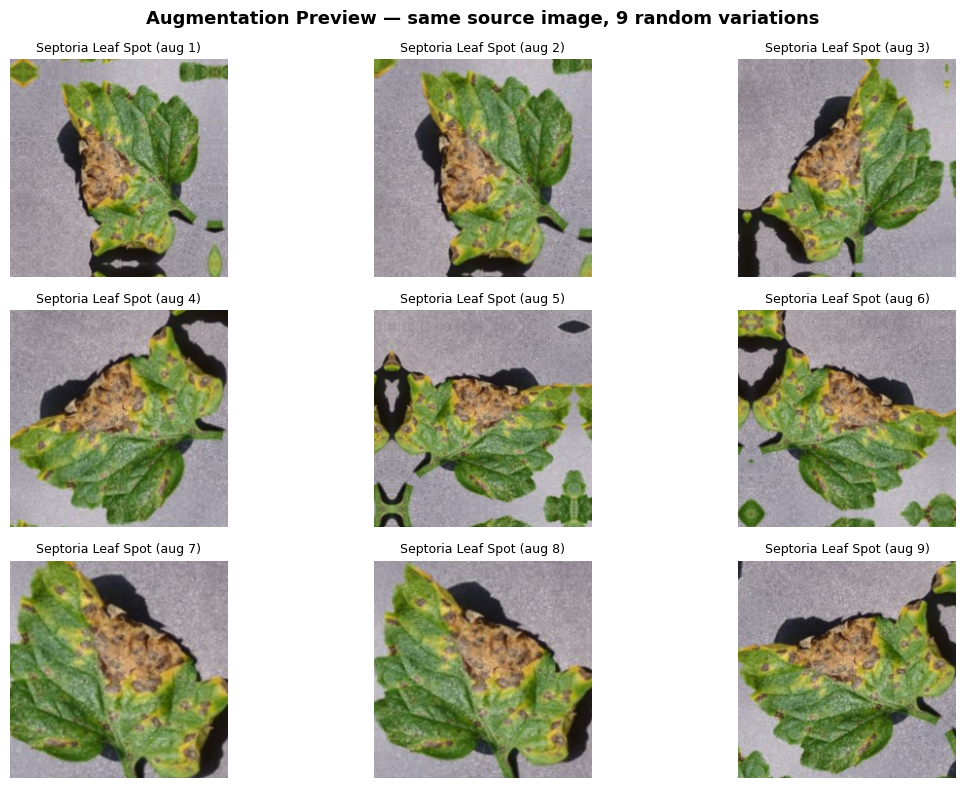

In [49]:
# Visualize what augmentation actually does to a real training image
for images, labels in train_dataset.take(1):
    sample_images = images.numpy()
    sample_labels = labels.numpy()

plt.figure(figsize=(12, 8))
first_image = sample_images[0]
label_idx = int(sample_labels[0][0])

for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    augmented = data_augmentation(tf.expand_dims(first_image, 0), training=True)
    plt.imshow(augmented[0].numpy().astype('uint8'))
    plt.title(f'{class_names[label_idx]} (aug {i+1})', fontsize=9)
    plt.axis('off')

plt.suptitle('Augmentation Preview — same source image, 9 random variations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [50]:
# STEP 6: Callbacks
def make_callbacks(name):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f'models/{name}_best.keras',
            monitor='val_accuracy', save_best_only=True,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=8,
            restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.3,
            patience=4, min_lr=1e-7, verbose=1,
        ),
    ]

def plot_learning_curves(history, title='Learning Curves'):
    acc, val_acc = history.history['accuracy'], history.history['val_accuracy']
    loss, val_loss = history.history['loss'], history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, linestyle='--')
    plt.legend(); plt.title(f'{title} — Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2, linestyle='--')
    plt.legend(); plt.title(f'{title} — Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(alpha=0.3)

    plt.tight_layout()
    safe_title = title.lower().replace(" ", "_")
    plt.savefig(results_dir + f'{safe_title}_curves.png', dpi=120, bbox_inches='tight')
    plt.show()

def evaluate_model(model, dataset, class_names, title='Model'):
    """Binary evaluation — single sigmoid output, threshold at 0.5."""
    y_true, y_pred, y_prob = [], [], []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0).ravel()
        preds = (probs >= 0.5).astype(int)
        y_prob.append(probs)
        y_pred.append(preds)
        y_true.append(labels.numpy().ravel().astype(int))
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    print(f"\n{title}")
    print(f'Accuracy : {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision: {precision_score(y_true, y_pred):.4f}')
    print(f'Recall   : {recall_score(y_true, y_pred):.4f}')
    print(f'F1-Score : {f1_score(y_true, y_pred):.4f}')
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, cmap='Blues', cbar=False, annot=True, fmt='d',
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={'fontsize': 11, 'fontweight': 'bold'})
    plt.title(f'{title} — Confusion Matrix')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout()
    safe_title = title.lower().replace(" ", "_")
    plt.savefig(results_dir + f'{safe_title}_confusion.png', dpi=120, bbox_inches='tight')
    plt.show()
    return accuracy_score(y_true, y_pred)

In [51]:
def build_transfer_model(input_shape, augmentation, base_trainable=False):
    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False, weights='imagenet', input_shape=input_shape
    )
    base_model.trainable = base_trainable

    inputs = tf.keras.Input(shape=input_shape)
    x = augmentation(inputs)
    x = tf.keras.applications.efficientnet.preprocess_input(x)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    return tf.keras.Model(inputs, outputs, name='efficientnet_transfer')

cnn_model = build_transfer_model(INPUT_SHAPE, data_augmentation)
cnn_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "efficientnet_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [52]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

cnn_history = cnn_model.fit(
    train_dataset, validation_data=val_dataset, epochs=EPOCHS,
    callbacks=make_callbacks('efficientnet_transfer'), verbose=1,
    class_weight=class_weight_dict,
)

Epoch 1/50


E0000 00:00:1785337577.603322      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/efficientnet_transfer_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


49/49 ━━━━━━━━━━━━━━━━━━━━ 21s 168ms/step - accuracy: 0.7473 - loss: 0.5442 - val_accuracy: 0.9006 - val_loss: 0.3531 - learning_rate: 0.0010
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.8620 - loss: 0.3665 - val_accuracy: 0.8976 - val_loss: 0.2714 - learning_rate: 0.0010
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.8936 - loss: 0.2974 - val_accuracy: 0.9217 - val_loss: 0.2283 - learning_rate: 0.0010
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - accuracy: 0.9084 - loss: 0.2480 - val_accuracy: 0.9307 - val_loss: 0.2021 - learning_rate: 0.0010
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.9123 - loss: 0.2404 - val_accuracy: 0.9307 - val_loss: 0.1852 - learning_rate: 0.0010
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.9220 - loss: 0.2188 - val_accuracy: 0.9458 - val_loss: 0.1650 - learning_rate: 0.0010
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - accuracy: 0.9420 - loss: 0.1835 - val_accuracy: 0

Custom CNN -> val_loss: 0.0654, val_accuracy: 0.9789


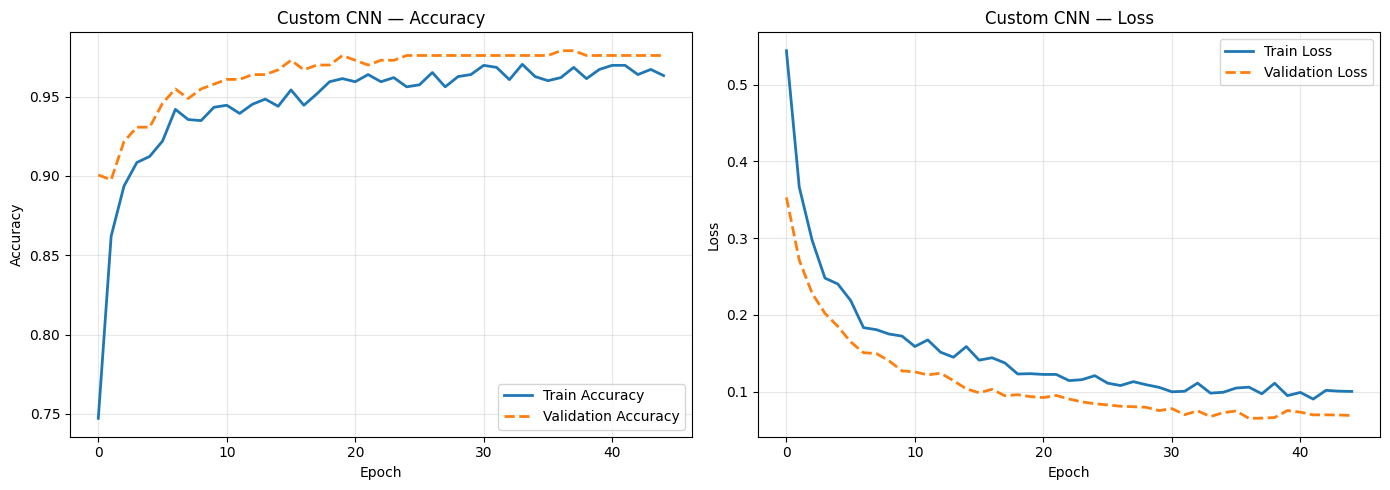

2026-07-29 15:09:41.664738: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Custom CNN
Accuracy : 0.9640
Precision: 0.9589
Recall   : 0.9859
F1-Score : 0.9722

Classification Report:
                    precision    recall  f1-score   support

         Leaf Mold     0.9737    0.9250    0.9487       120
Septoria Leaf Spot     0.9589    0.9859    0.9722       213

          accuracy                         0.9640       333
         macro avg     0.9663    0.9555    0.9605       333
      weighted avg     0.9642    0.9640    0.9638       333



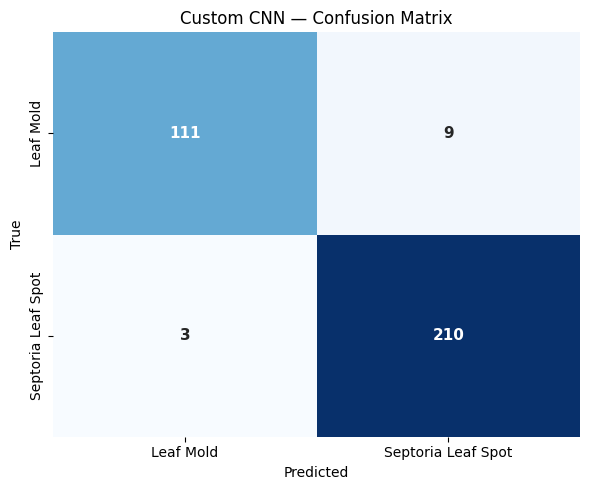

In [53]:
# STEP: Evaluate
cnn_val_loss, cnn_val_acc = cnn_model.evaluate(val_dataset, verbose=0)
print(f'Custom CNN -> val_loss: {cnn_val_loss:.4f}, val_accuracy: {cnn_val_acc:.4f}')

plot_learning_curves(cnn_history, 'Custom CNN')
cnn_test_acc = evaluate_model(cnn_model, test_dataset, class_names, 'Custom CNN')